In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy 
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
ds = xr.open_dataset('data/raw/smvi/FD_Events_NC/FD_Events_2016.nc')

In [4]:
print(ds.data_vars)

Data variables:
    fstdate1  (lat, lon) float64 7MB ...
    lstdate1  (lat, lon) float64 7MB ...
    fstdate2  (lat, lon) float64 7MB ...
    lstdate2  (lat, lon) float64 7MB ...
    fstdate3  (lat, lon) float64 7MB ...
    lstdate3  (lat, lon) float64 7MB ...
    fstdate4  (lat, lon) float64 7MB ...
    lstdate4  (lat, lon) float64 7MB ...
    fstdate5  (lat, lon) float64 7MB ...
    lstdate5  (lat, lon) float64 7MB ...
    fstdate6  (lat, lon) float64 7MB ...
    lstdate6  (lat, lon) float64 7MB ...
    SV1       (lat, lon) float64 7MB ...
    SV2       (lat, lon) float64 7MB ...
    SV3       (lat, lon) float64 7MB ...
    SV4       (lat, lon) float64 7MB ...
    SV5       (lat, lon) float64 7MB ...
    SV6       (lat, lon) float64 7MB ...
    VEGID     (lat, lon) float64 7MB ...
    LON       (lat, lon) float64 7MB ...
    LAT       (lat, lon) float64 7MB ...


In [5]:
ds.load()

<xarray.Dataset> Size: 145MB
Dimensions:   (lat: 600, lon: 1440)
Coordinates:
  * lat       (lat) float64 5kB -59.88 -59.62 -59.38 ... 89.38 89.62 89.88
  * lon       (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables: (12/21)
    fstdate1  (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    lstdate1  (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    fstdate2  (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    lstdate2  (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    fstdate3  (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    lstdate3  (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    ...        ...
    SV4       (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    SV5       (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    SV6       (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    VEGID     (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    LON       (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
    LAT       (lat, lon) float64 7MB nan nan nan nan nan ... nan nan nan nan nan
Attributes:
    Conventions:  CF-1.6, ACDD-1.3
    title:        Global SMVI events dataset
    institution:  Johns Hopkins University
    source:       
    history:      Created 2024-05-28T19:21:50.826228
    references:   Osman, M. et al. Flash drought onset over the contiguous Un...
    comment:      This file contains SMVI event data mapped to GLDAS grid.

In [6]:
ds_se = ds.sel(
    lat=slice(30.0, 35.0),
    lon=slice(-89.0, -81.6)
)

In [7]:
import numpy as np

onset1 = ds_se["fstdate1"]

print("non-NaN count:", np.count_nonzero(~np.isnan(onset1.values)))
print("min raw value:", np.nanmin(onset1.values))
print("max raw value:", np.nanmax(onset1.values))

non-NaN count: 52
min raw value: 149.0
max raw value: 305.0


In [8]:
vals = onset1.values.flatten()
vals = vals[~np.isnan(vals)]

print(vals[:20])

[192. 290. 293. 299. 305. 289. 293. 294. 287. 290. 300. 296. 280. 291.
 271. 298. 296. 295. 272. 300.]


In [9]:
import pandas as pd
import numpy as np

vals = ds_se["fstdate1"].values.flatten()
vals = vals[~np.isnan(vals)]

onset_dates = pd.to_datetime(vals.astype(int) - 1, unit="D", origin="2016-01-01")

print(onset_dates[:20])
print("min:", onset_dates.min())
print("median:", pd.Series(onset_dates).median())
print("max:", onset_dates.max())

DatetimeIndex(['2016-07-10', '2016-10-16', '2016-10-19', '2016-10-25',
               '2016-10-31', '2016-10-15', '2016-10-19', '2016-10-20',
               '2016-10-13', '2016-10-16', '2016-10-26', '2016-10-22',
               '2016-10-06', '2016-10-17', '2016-09-27', '2016-10-24',
               '2016-10-22', '2016-10-21', '2016-09-28', '2016-10-26'],
              dtype='datetime64[ns]', freq=None)
min: 2016-05-28 00:00:00
median: 2016-09-27 12:00:00
max: 2016-10-31 00:00:00


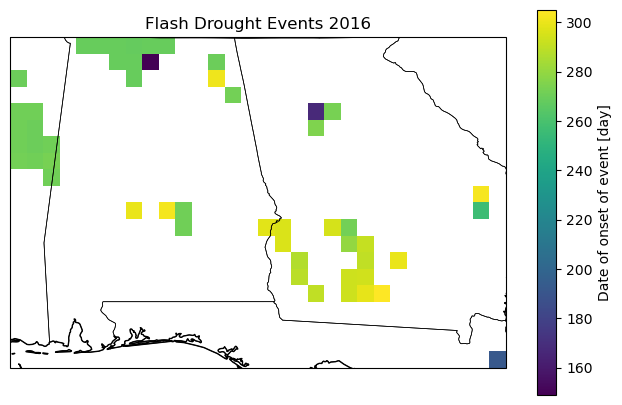

In [19]:
onset1 = ds_se["fstdate1"]
onset1.name = "SMVI_onset_doy"
#onset1.plot(figsize=(8, 6))

fig, ax = plt.subplots(figsize=(8, 5), subplot_kw={'projection': ccrs.PlateCarree()})
onset1.plot()
ax.set_title("Flash Drought Events 2016")
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE)

In [15]:
import numpy as np

lon2d, lat2d = np.meshgrid(onset1['lon'], onset1['lat'])
values = onset1.values

mask = ~np.isnan(values)

lon_valid = lon2d[mask]
lat_valid = lat2d[mask]
val_valid = values[mask]


onset1 = ds_se["fstdate1"]
onset1.name = "SMVI_onset_doy"

fig, ax = plt.subplots(figsize=(8, 5),
                       subplot_kw={'projection': ccrs.PlateCarree()})

sc = ax.scatter(
    lon_valid,
    lat_valid,
    c=val_valid,
    cmap='viridis',
    s=40,
    edgecolor='k',
    transform=ccrs.PlateCarree()
)

ValueError: x and y must be the same size

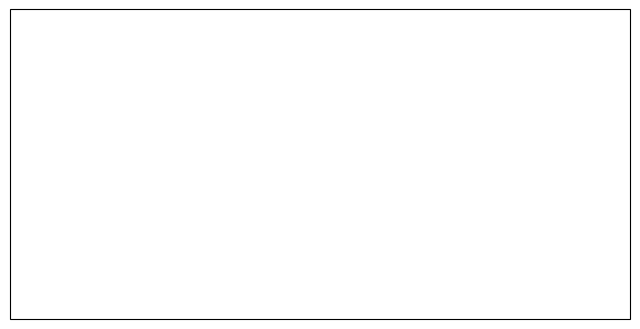

In [16]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

onset1 = ds_se["fstdate1"]
onset1.name = "SMVI_onset_doy"

fig, ax = plt.subplots(figsize=(8, 5),
                       subplot_kw={'projection': ccrs.PlateCarree()})

# Convert to scatter: use lon/lat + values
sc = ax.scatter(
    onset1['lon'], 
    onset1['lat'], 
    c=onset1.values,
    cmap='viridis',
    s=40,              # size of circles
    edgecolor='k',     # outline for clarity
    transform=ccrs.PlateCarree()
)

# Add colorbar (shows date values)
cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
cbar.set_label("Onset Date (DOY)")

# Map features
ax.add_feature(cfeature.STATES, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.COASTLINE)

plt.show()

In [12]:
regional_onset = pd.Series(onset_dates).median()
print(regional_onset)

2016-09-27 12:00:00


In [13]:
import pandas as pd
import numpy as np

vals = ds_se["fstdate1"].values.flatten()
vals = vals[~np.isnan(vals)]

onset_dates = pd.to_datetime(vals.astype(int) - 1, unit="D", origin="2016-01-01")

<Axes: >

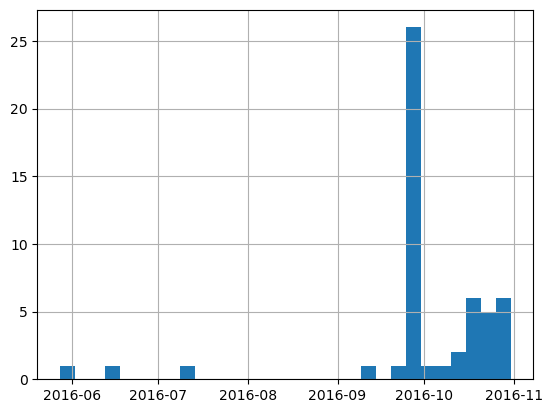

In [14]:
pd.Series(onset_dates).hist(bins=30)

<Axes: >

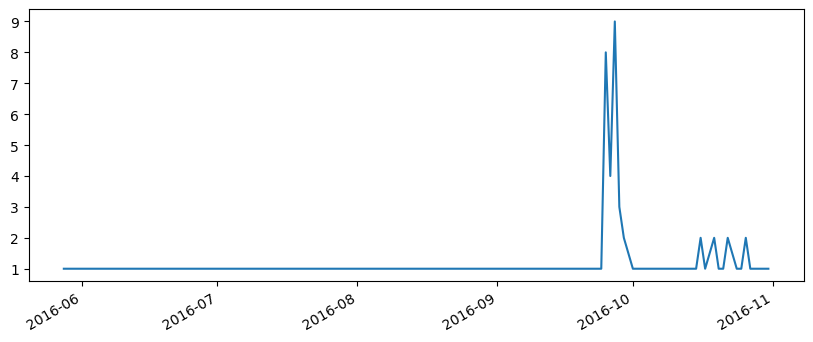

In [15]:
onset_series = pd.Series(onset_dates)

counts = onset_series.value_counts().sort_index()

counts.plot(figsize=(10,4))